# Tranfer learning MobileNetV2 for 3 classification Chapter 10 Workshop 5

## Load module

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

## Declare variable

In [2]:
target_size = (128, 128)

train_dir = r'D:\Project\Learning\TensorFlow_Files\datasets\ele_cat_dog\train_set'
val_dir = r"D:\Project\Learning\TensorFlow_Files\datasets\ele_cat_dog\val_set"

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    batch_size=32,
    class_mode='sparse',
)

val_datagen = ImageDataGenerator(
                            preprocessing_function=preprocess_input,
                            rotation_range=20,
                            width_shift_range=0.15,
                            height_shift_range=0.15,
                            shear_range=0.2,
                            zoom_range=0.2,
                            horizontal_flip=True,
                            fill_mode='nearest'
)

val_set = val_datagen.flow_from_directory(val_dir,
                                                  target_size=target_size,
                                                  batch_size=32,
                                                  class_mode='sparse')

Found 150 images belonging to 3 classes.
Found 41 images belonging to 3 classes.


## Check dataset

In [3]:
print(train_set.class_indices)

ids, counts = np.unique(train_set.classes, return_counts=True)
print(ids)
print(counts)

{'cat': 0, 'dog': 1, 'elephant': 2}
[0 1 2]
[50 50 50]


In [4]:
labels = train_set.class_indices
labels = {v: k for k, v in labels.items()}
print(labels)
for i in ids:
    print(labels[i], counts[i])

{0: 'cat', 1: 'dog', 2: 'elephant'}
cat 50
dog 50
elephant 50


In [5]:
_, train_count = np.unique(train_set.classes, return_counts=True)
_, val_count = np.unique(val_set.classes, return_counts=True)

# Val/Train ratio not less than 0.1 (10%)
print(f"Ratio Val/Train set: {val_count/train_count*100}")

Ratio Val/Train set: [32. 30. 20.]


## Create Tranfer MobileNetV2 model

### Declare input shape

In [6]:
in_shape = (target_size[0], target_size[1], 3)

### load base model (base layer)

In [7]:
base_model = MobileNetV2(input_shape=in_shape, 
                         include_top=False, 
                         weights='imagenet')

base_model.summary()

9406464/9406464 [==============================] - 2s 0us/step
Model: "mobilenetv2_1.00_128"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 64, 64, 32)   864         ['input_1[0][0]']                
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 64, 64, 32)   128         ['Conv1[0][0]']                  
                                                                                                  
 Conv1_relu (ReL

### Add classication layer

In [8]:
tranfer_model = Sequential()

tranfer_model.add(base_model)
tranfer_model.add(Flatten())
tranfer_model.add(Dense(256, activation='relu'))
tranfer_model.add(Dropout(0.4))
tranfer_model.add(Dense(128, activation='relu'))
tranfer_model.add(Dropout(0.4))
tranfer_model.add(Dense(3, activation='softmax'))
tranfer_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_128 (Funct  (None, 4, 4, 1280)       2257984   
 ional)                                                          
                                                                 
 flatten (Flatten)           (None, 20480)             0         
                                                                 
 dense (Dense)               (None, 256)               5243136   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                        

## Freeze base model

In [9]:
base_model.trainable = False
tranfer_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_128 (Funct  (None, 4, 4, 1280)       2257984   
 ional)                                                          
                                                                 
 flatten (Flatten)           (None, 20480)             0         
                                                                 
 dense (Dense)               (None, 256)               5243136   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                        

## Compile tranfer mobilenet_v2 model

In [10]:
tranfer_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])


## Train tranfer mobilenet_v2 model

In [12]:
es = EarlyStopping(monitor='val_loss',
                   patience=5,
                   verbose=1,
                   restore_best_weights=True)

model_path = r"D:\Project\Learning\TensorFlow_Files\model\3_classes_tranfer_MobileNetV2_model.h5"
mc = ModelCheckpoint(model_path,
                     monitor='val_accuracy',
                     save_best_only=True,
                     verbose=1)

history = tranfer_model.fit(
                        train_set,
                        steps_per_epoch=len(train_set),
                        validation_steps=len(val_set),
                        validation_data=val_set,
                        epochs=20,
                        callbacks=[es, mc],
                        verbose=1
)

Epoch 1/20
5/5 [==============================] - ETA: 0s - loss: 1.2919 - accuracy: 0.7867
Epoch 1: val_accuracy improved from -inf to 0.87805, saving model to D:\Project\Learning\TensorFlow_Files\model\3_classes_tranfer_resnet50_model.h5
5/5 [==============================] - 1s 290ms/step - loss: 1.2919 - accuracy: 0.7867 - val_loss: 0.8050 - val_accuracy: 0.8780
Epoch 2/20
5/5 [==============================] - ETA: 0s - loss: 1.0818 - accuracy: 0.8600
Epoch 2: val_accuracy improved from 0.87805 to 0.90244, saving model to D:\Project\Learning\TensorFlow_Files\model\3_classes_tranfer_resnet50_model.h5
5/5 [==============================] - 1s 270ms/step - loss: 1.0818 - accuracy: 0.8600 - val_loss: 0.8198 - val_accuracy: 0.9024
Epoch 3/20
5/5 [==============================] - ETA: 0s - loss: 0.9358 - accuracy: 0.8800
Epoch 3: val_accuracy did not improve from 0.90244
5/5 [==============================] - 1s 207ms/step - loss: 0.9358 - accuracy: 0.8800 - val_loss: 0.8509 - val_accu

## Evaluate model

In [13]:
score = tranfer_model.evaluate(val_set, verbose=1)
print(f"Test loss: {round(score[0],3)}")
print(f"Test accuracy: {round(score[1],3)}")

2/2 [==============================] - 0s 24ms/step - loss: 0.6023 - accuracy: 0.8780
Test loss: 0.602
Test accuracy: 0.878


## Visualization

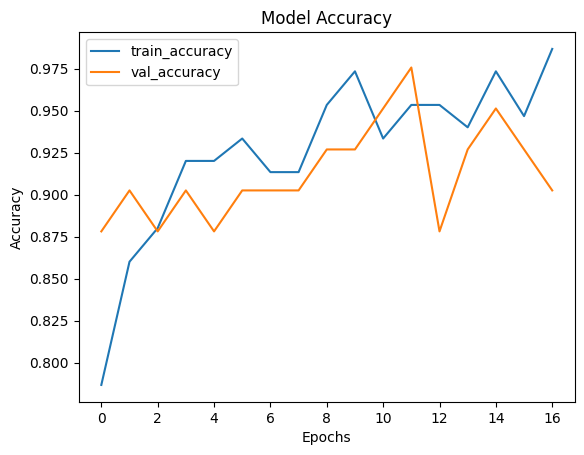

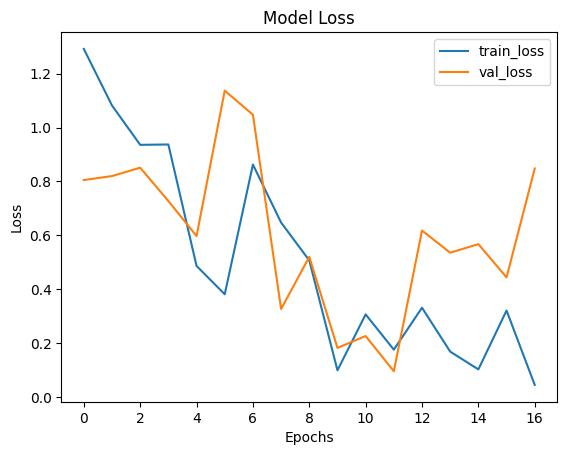

In [14]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

## Prediction

### Declare predict function

In [15]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_image(model, image_path):
    img = load_img(image_path, target_size=(128, 128))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    pred = model.predict(img)
    pred_class = labels[np.argmax(pred, axis=1)[0]]
    print(f"Predicted class: {pred_class}", pred[0].round(5))

In [22]:
image_path = r"D:\Project\Learning\TensorFlow_Files\datasets\ele_cat_dog\test_set\dog3.jpg"
predict_image(tranfer_model, image_path)

1/1 [==============================] - 0s 16ms/step
Predicted class: dog [0. 1. 0.]
